In [7]:
import numpy as np
import pandas as pd
import xgboost as xgb
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import jaccard_score, accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load CSVs and automatically assign IDs
resumes = pd.read_csv("C:/Users/Acer/Desktop/ARSwithPredictiveAnalytics/Data-Training/notebooks/all_resumes_extractedentity.csv")
jobs = pd.read_csv("C:/Users/Acer/Desktop/ARSwithPredictiveAnalytics/Data-Training/notebooks/all_jobreq_extractedentity.csv")

# Add auto-incrementing IDs if they don't exist
if 'resume_id' not in resumes.columns:
    resumes.insert(0, 'resume_id', range(1, len(resumes) + 1))

if 'job_id' not in jobs.columns:
    jobs.insert(0, 'job_id', range(1, len(jobs) + 1))

# Label encoding job titles
label_encoder = LabelEncoder()
jobs['encoded_job_title'] = label_encoder.fit_transform(jobs['job_title'])

# Function to compute Jaccard Similarity
def compute_jaccard_similarity(text1, text2):
    set1, set2 = set((text1).split()), set( (text2).split())
    return len(set1 & set2) / len(set1 | set2) if len(set1 | set2) > 0 else 0

# Compute Jaccard Similarity between resumes and job descriptions
jaccard_scores = []
resume_ids, job_ids, job_labels = [], [], []

for _, resume in resumes.iterrows():
    for _, job in jobs.iterrows():
        score = compute_jaccard_similarity(resume['preprocessed_text'], job['preprocessed_text'])
        jaccard_scores.append(score)
        resume_ids.append(resume['resume_id'])
        job_ids.append(job['job_id'])
        job_labels.append(job['encoded_job_title'])

# Create DataFrame
X = pd.DataFrame({'resume_id': resume_ids, 'job_id': job_ids, 'jaccard_score': jaccard_scores})
y = np.array(job_labels)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X[['jaccard_score']], y, test_size=0.2, random_state=42)

# Train XGBoost model
model = xgb.XGBClassifier(objective='multi:softprob', eval_metric='mlogloss')
model.fit(X_train, y_train)

# Predict job titles for resumes
predictions = model.predict(X_test)
predicted_titles = label_encoder.inverse_transform(predictions)
actual_titles = label_encoder.inverse_transform(y_test)

# Determine suitability
def get_suitability(score):
    if score >= 0.75:
        return "Highly Suitable"
    elif score >= 0.50:
        return "Mildly Suitable"
    elif score >= 0.25:
        return "Less Suitable"
    else:
        return "Not Suitable"

X_test['predicted_job_title'] = predicted_titles
X_test['suitability'] = X_test['jaccard_score'].apply(get_suitability)

In [8]:

# ===== Model Evaluation =====
accuracy = accuracy_score(y_test, predictions)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, predictions, average='weighted')
conf_matrix = confusion_matrix(y_test, predictions)

print("Model Evaluation:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


Model Evaluation:
Accuracy: 0.04
Precision: 0.03
Recall: 0.04
F1 Score: 0.03


c:\Users\Acer\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


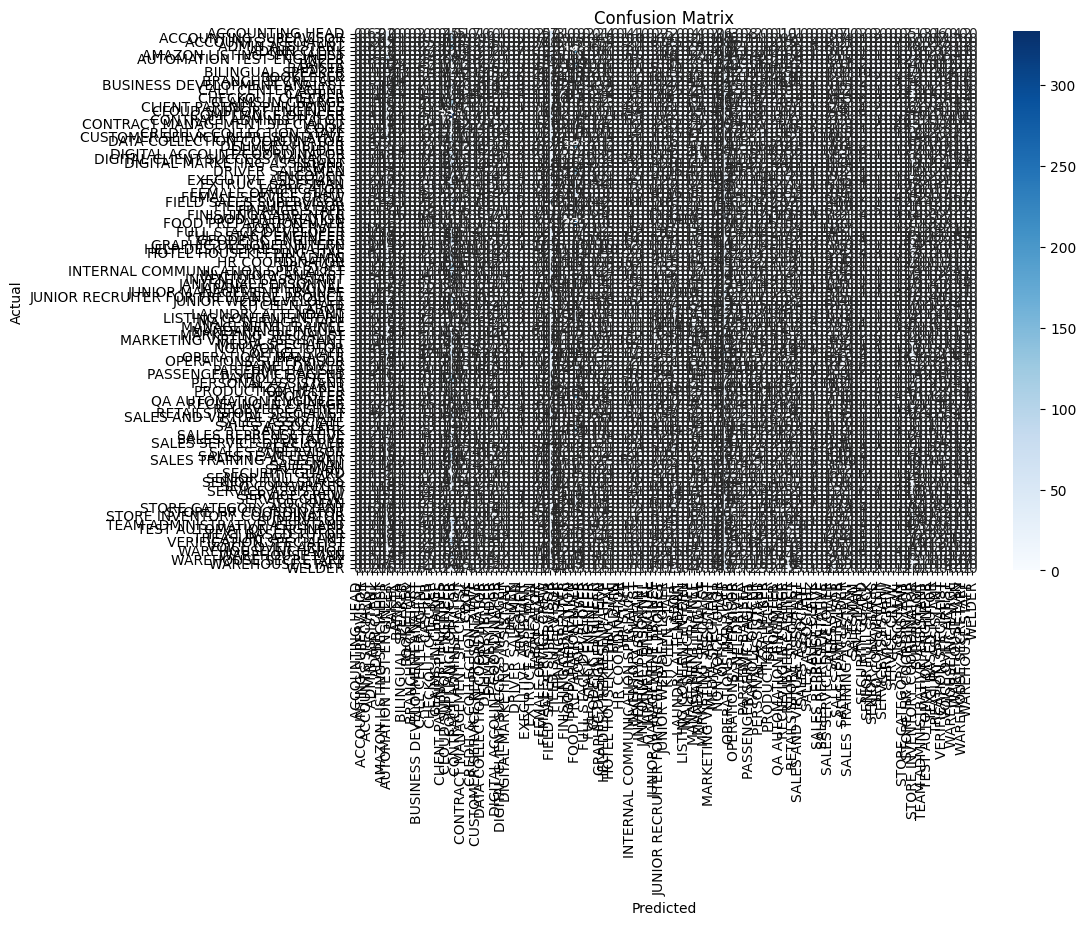

In [9]:
# Plot Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()